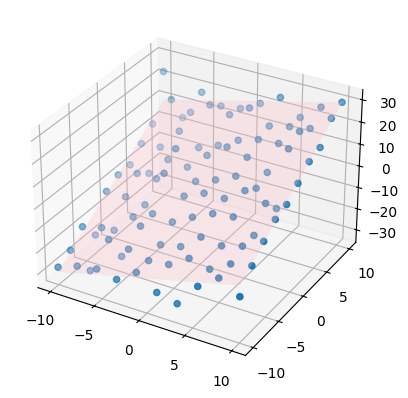

In [133]:
import numpy as np
import matplotlib.pyplot as plt

a, b, c = 1, 2, -1

x = np.linspace(-10, 10, 10)
y = np.linspace(-10, 10, 10)
X, Y = np.meshgrid(x, y)
Z = (-a*X - b*Y) / c

x_flat = X.flatten()
y_flat = Y.flatten()
z_flat = Z.flatten() + np.random.normal(0, 5, 100)

points = np.stack([x_flat, y_flat, z_flat], axis=1)

fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.scatter(points[:,0], points[:,1], points[:,2])
ax.plot_surface(X, Y, Z, alpha=0.3, color='pink')
plt.show()




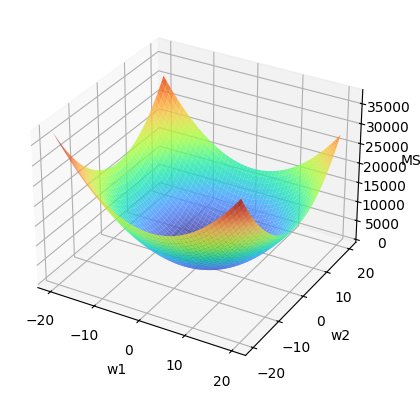

In [134]:
def prediction(w1,w2,x,y):
    return w1*x+ w2*y

def MSE(w1,w2,x,y,z):
    pred = prediction(w1,w2,x,y)
    return np.mean((pred-z)**2)

w1range = np.linspace(-20,20,50)
w2range = np.linspace(-20,20,50)

w1grid, w2grid = np.meshgrid(w1range, w2range)

loss = np.zeros_like(w1grid)
for i in range(w1grid.shape[0]):
    for j in range(w1grid.shape[1]):
        loss[i,j] = MSE(w1grid[i,j], w2grid[i,j], x_flat, y_flat, z_flat)

fig = plt.figure()
ax = fig.add_subplot(projection = '3d')
ax.plot_surface(w1grid, w2grid, loss, cmap='turbo', alpha=0.8)
ax.set_xlabel('w1')
ax.set_ylabel('w2')
ax.set_zlabel('MSE')
plt.show()


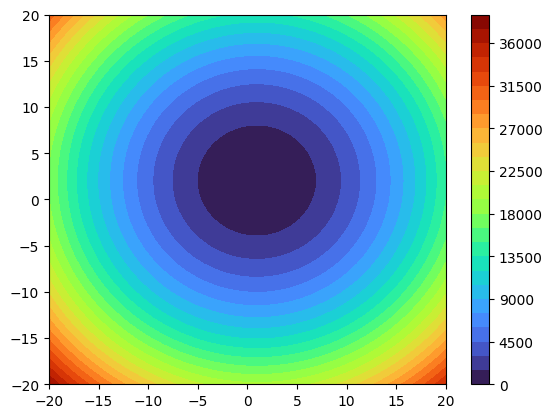

In [135]:
fig, ax = plt.subplots()
contour = ax.contourf(w1grid, w2grid, loss, levels=30, cmap='turbo')
plt.colorbar(contour)

plt.show()



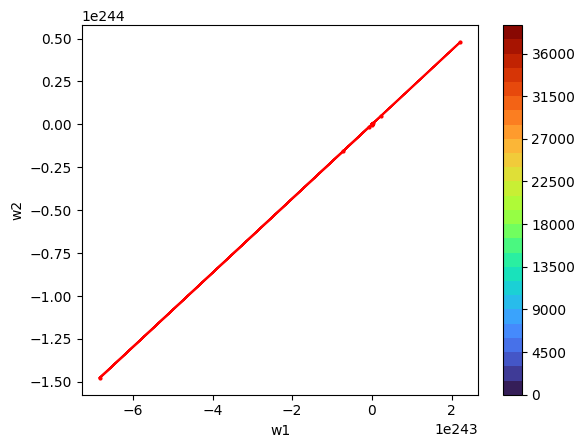

In [136]:
def gradient(w1,w2,x,y,z):
    prediction = w1*x + w2 * y
    error = prediction - z
    dw1 = np.mean(2 * error * x)
    dw2 = np.mean(2 * error * y)
    return dw1, dw2



w1_path = [0.0]
w2_path = [0.0]
w1, w2 = 0.0, 0.0
lr = 0.05

for i in range(500):
    dw1, dw2 = gradient(w1, w2, x_flat, y_flat, z_flat)
    w1 -= lr * dw1
    w2 -= lr * dw2
    w1_path.append(w1)
    w2_path.append(w2)

fig, ax = plt.subplots()
contour = ax.contourf(w1grid, w2grid, loss, levels=30, cmap='turbo')
ax.plot(w1_path, w2_path, color='red', marker='o', markersize=2)
ax.set_xlabel('w1')
ax.set_ylabel('w2')
plt.colorbar(contour)
plt.show()




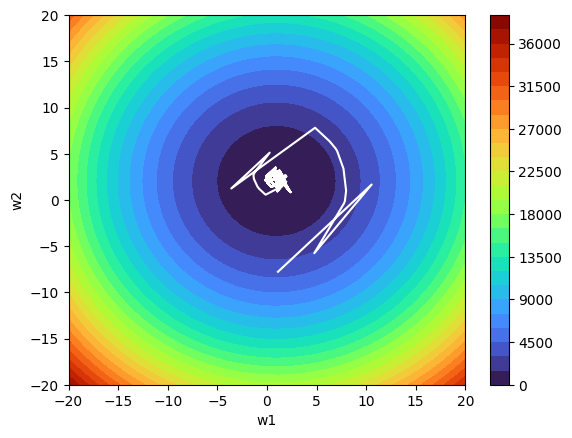

In [137]:
startingsample = np.random.randint(0, len(x_flat))
w1_start = x_flat[startingsample]
w2_start = y_flat[startingsample]

w1_path_sgd = [w1_start]
w2_path_sgd = [w2_start]
w1, w2 = w1_start, w2_start
lr = 0.005
epochs = 5
for epoch in range(epochs):
    for i in range(len(x_flat)):
        xi = x_flat[i]
        yi = y_flat[i]
        zi = z_flat[i]
        dw1, dw2 = gradient(w1, w2, xi, yi, zi)
        w1 -= lr * dw1
        w2 -= lr * dw2
        w1_path_sgd.append(w1)
        w2_path_sgd.append(w2)
fig, ax = plt.subplots()
contour = ax.contourf(w1grid, w2grid, loss, levels=30, cmap='turbo')
ax.plot(w1_path_sgd, w2_path_sgd, color='white')
ax.set_xlabel('w1')
ax.set_ylabel('w2')
plt.colorbar(contour)
plt.show()


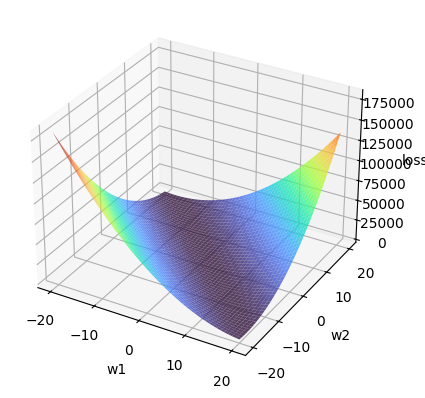

In [138]:
xi = x_flat[0]
yi = y_flat[0]
zi = z_flat[0]
loss_i = (w1grid*xi + w2grid*yi - zi)**2

fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.plot_surface(w1grid, w2grid, loss_i, cmap='turbo', alpha=0.8)
ax.set_xlabel('w1')
ax.set_ylabel('w2')
ax.set_zlabel('loss')
plt.show()

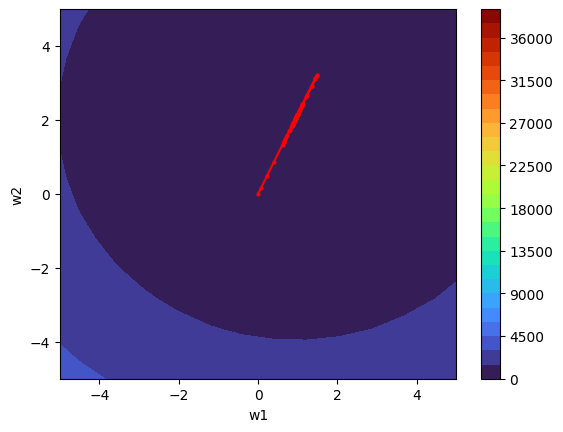

In [139]:
w1_path_momentum = [0.0]
w2_path_momentum = [0.0]
w1, w2 = 0.0, 0.0
v1, v2 = 0.0, 0.0
lr = 0.01
beta = 0.9
for i in range(500):
    dw1, dw2 = gradient(w1, w2, x_flat, y_flat, z_flat)
    v1 = beta * v1 + (1 - beta) * dw1
    v2 = beta * v2 + (1 - beta) * dw2
    w1 = w1 - lr * v1
    w2 = w2 - lr * v2
    w1_path_momentum.append(w1)
    w2_path_momentum.append(w2)
fig, ax = plt.subplots()
contour = ax.contourf(w1grid, w2grid, loss, levels=30, cmap='turbo')
ax.plot(w1_path_momentum, w2_path_momentum, color='red', marker='o', markersize=2)
ax.set_xlabel('w1')
ax.set_ylabel('w2')
ax.set_xlim(-5, 5)
ax.set_ylim(-5, 5)
plt.colorbar(contour)
plt.show()




In [140]:
#formula for adagrad:
#theta = theta_(t-1) - (n)/(sqrt(G_t-1)+e)*g_t
#where G = G_t-1 + gradient(loss wrt weights)

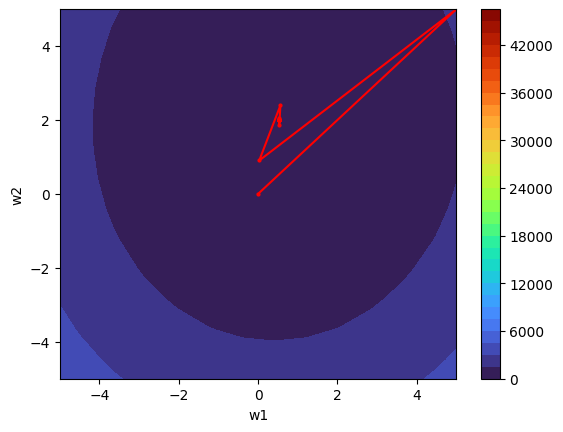

In [131]:
w1_path_adagrad = [0.0]
w2_path_adagrad = [0.0]
w1, w2 = 0.0, 0.0
G1, G2 = 0.0, 0.0
lr = 5
eps = 1e-5
for i in range(500):
    dw1, dw2 = gradient(w1, w2, x_flat, y_flat, z_flat)
    G1 = G1 + dw1**2
    G2 = G2 + dw2**2
    w1 = w1 - lr/(np.sqrt(G1)+eps) * dw1
    w2 = w2 - lr/(np.sqrt(G2)+eps) * dw2
    w1_path_adagrad.append(w1)
    w2_path_adagrad.append(w2)
fig, ax = plt.subplots()
contour = ax.contourf(w1grid, w2grid, loss, levels=30, cmap='turbo')
ax.plot(w1_path_adagrad, w2_path_adagrad, color='red', marker='o', markersize=2)
ax.set_xlabel('w1')
ax.set_ylabel('w2')
ax.set_xlim(-5, 5)
ax.set_ylim(-5, 5)
plt.colorbar(contour)
plt.show()

